**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2025*

----

# Trabajo práctico entregable - parte 1

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [365]:
import matplotlib.pyplot as plt
import numpy
import pandas

import seaborn
seaborn.set_context('talk')

from sqlalchemy import create_engine, text

In [366]:
import plotly
plotly.__version__


'5.24.1'

In [367]:
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar: df.to_sql() infiere tipos automáticamente, pero a veces los nombres de columnas como Date, Price o ID dan problemas si vienen con strings o valores nulos.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por ciudad.
    - cantidad de registros totales por barrio y ciudad.
    - Consulta con filtro: ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL  para obtener un resultado similar a lo realizado con Pandas en clase.  



# Respuesta - Ejercicio 1

In [368]:
# 1.1)
# Crear base de datos
from sqlalchemy import create_engine, text
import io

engine = create_engine("sqlite:///foo.db")

***

In [369]:
# 1.2)
# Subir archivo .csv de la clase anterior
import os
from google.colab import files

uploaded = files.upload()
filename = 'airbnb_price_by_zipcode.csv'

if os.path.exists(filename):
    os.remove(filename)

airbnb_df = pandas.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

Saving airbnb_price_by_zipcode.csv to airbnb_price_by_zipcode.csv


***

In [370]:
# 1.3)
# Reviso dtypes de cada columna
airbnb_df.info()
print("\n++++++++++++++++++++++++++\n")
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   zipcode                    247 non-null    float64
 1   airbnb_price_mean          247 non-null    float64
 2   airbnb_record_count        247 non-null    int64  
 3   airbnb_weekly_price_mean   184 non-null    float64
 4   airbnb_monthly_price_mean  168 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 9.8 KB

++++++++++++++++++++++++++

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Met

In [371]:
# Observo cuáles son las columnas con valores nulos (strings vacíos, NaNs...)
missing_values_airbnb_df = airbnb_df.isnull().sum()
missing_values_airbnb_df[missing_values_airbnb_df > 0]

,0
airbnb_weekly_price_mean,63
airbnb_monthly_price_mean,79


In [372]:
missing_values_melb = melb_df.isnull().sum()
missing_values_melb[missing_values_melb > 0]

,0
Car,62
BuildingArea,6450
YearBuilt,5375
CouncilArea,1369


> ...pero a veces los nombres de columnas como Date, **Price** o ID dan problemas si vienen con strings o valores nulos.

Acorde a la consigna, las columnas de **precio** que poseen valores nulos (y que pueden ser conflictivos) están dentro de `airbnb_df` y son:

`airbnb_weekly_price_mean, airbnb_monthly_price_mean`

Podría implementar dos opciones:

1. Eliminar todas aquellas filas que contengan un valor nulo.
2. Reemplazar el valor nulo `NaN` de esas filas por un valor `0` (interpretándolo como un valor no especificado en la aplicación).  

Elijo la segunda opción.

In [373]:
airbnb_df = airbnb_df.fillna(0)

airbnb_df.to_sql('airbnb_table', con=engine, if_exists='replace')
melb_df.to_sql('melb_table', con=engine, if_exists='replace')

13580

***

In [374]:
# 1.4)

query1 = """
SELECT COUNT(*) FROM melb_table
"""

result = pandas.read_sql(query1, con=engine)
print("Cantidad de registros totales por ciudad: \n%s" %result)

query2 = """
SELECT Suburb, COUNT(*) FROM melb_table GROUP BY Suburb
"""

result = pandas.read_sql(query2, con=engine)
print("\nCantidad de registros totales por barrio y ciudad: \n%s" %result.head())

query3 = """
SELECT COUNT(*) FROM melb_table WHERE Rooms > 2
"""

result = pandas.read_sql(query3, con=engine)
print("\nCantidad de registros con más de 2 habitaciones: \n%s" %result)

query4 = """
SELECT Type, AVG(Price) as precio_promedio FROM melb_table GROUP BY Type
"""

result = pandas.read_sql(query4, con=engine)

print("\n Precio promedio por Type: \n%s" %result)

query5 = """
SELECT Suburb, AVG(Price) as precio_promedio FROM melb_table GROUP BY Suburb ORDER BY precio_promedio DESC LIMIT 5
"""

result = pandas.read_sql(query5, con=engine)

print("\n Top 5 barrios con precios promedio más caros: \n%s" %result)


Cantidad de registros totales por ciudad: 
   COUNT(*)
0     13580

Cantidad de registros totales por barrio y ciudad: 
         Suburb  COUNT(*)
0    Abbotsford        56
1    Aberfeldie        44
2  Airport West        67
3     Albanvale         6
4   Albert Park        69

Cantidad de registros con más de 2 habitaciones: 
   COUNT(*)
0      9251

 Precio promedio por Type: 
  Type  precio_promedio
0    h     1.242665e+06
1    t     9.337351e+05
2    u     6.051275e+05

 Top 5 barrios con precios promedio más caros: 
        Suburb  precio_promedio
0      Kooyong     2.185000e+06
1   Canterbury     2.180241e+06
2  Middle Park     2.082529e+06
3  Albert Park     1.941355e+06
4     Brighton     1.930158e+06


In [375]:
# 1.5)

query6 = """
SELECT * FROM melb_table
JOIN airbnb_table
ON melb_table.Postcode = airbnb_table.zipcode
"""

result = pandas.read_sql(query6, con=engine)
result.head()

,index,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Lattitude,Longtitude,Regionname,Propertycount,index,zipcode,airbnb_price_mean,airbnb_record_count,airbnb_weekly_price_mean,airbnb_monthly_price_mean
0,0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,-37.7996,144.9984,Northern Metropolitan,4019.0,57,3067.0,130.624031,258,605.152174,2187.032258
1,1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,-37.8079,144.9934,Northern Metropolitan,4019.0,57,3067.0,130.624031,258,605.152174,2187.032258
2,2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,-37.8093,144.9944,Northern Metropolitan,4019.0,57,3067.0,130.624031,258,605.152174,2187.032258
3,3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,-37.7969,144.9969,Northern Metropolitan,4019.0,57,3067.0,130.624031,258,605.152174,2187.032258
4,4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,-37.8072,144.9941,Northern Metropolitan,4019.0,57,3067.0,130.624031,258,605.152174,2187.032258


## Ejercicio 2 - Pandas:

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2.  Mostrar la dispersión o distribución de las columnas seleccionadas.
 3.  Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás



2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?

# Respuesta - Ejercicio 2

Me voy a enfocar en las siguientes columnas:

```
interesting_cols = ['Rooms', 'Distance', 'Type', 'Price',
                    'YearBuilt', 'Bedroom2', 'Bathroom', 'Car',
                    'Landsize', 'BuildingArea', 'YearBuilt', 'Suburb']
```

Considero que columnas tales como:

```
Address, Regionname, Propertycount, CouncilArea, Longtitude, Lattitude
```

Nos dan información muy específica de el lugar/espacio de la propiedad, pero no características más importantes como por ejemplo, la cantidad de habitaciones que tiene.

Y descarto columnas como:

```
SellerG, Method
```

Ya que se relacionan más con el proceso de venta que propiedades estructurales de la propiedad en sí.

In [376]:
# 2.1.1)

interesting_cols = ['Rooms', 'Distance', 'Type', 'Price',
                    'YearBuilt', 'Bedroom2', 'Bathroom', 'Car',
                    'Landsize', 'BuildingArea', 'YearBuilt', 'Suburb']

# Creo un nuevo df con las columnas que me interesan y me fijo el porcentaje de filas vacías por columna
selected_cols_df = melb_df[interesting_cols].copy()
selected_cols_df.isnull().mean() * 100

,0
Rooms,0.000000
Distance,0.000000
Type,0.000000
Price,0.000000
YearBuilt,39.580265
Bedroom2,0.000000
Bathroom,0.000000
Car,0.456554
Landsize,0.000000
BuildingArea,47.496318


Como el porcentaje es bastante alto en `BuildingArea` y `YearBuilt`, decido descartar esas columnas. Para `Car` elimino las pocas filas que no tienen valor definido.



In [377]:
selected_cols_df = selected_cols_df.drop("BuildingArea", axis=1)
selected_cols_df = selected_cols_df.drop("YearBuilt", axis=1)

In [378]:
selected_cols_df = selected_cols_df.dropna(subset=['Car'])

In [379]:
selected_cols_df.isnull().mean() * 100

,0
Rooms,0.0
Distance,0.0
Type,0.0
Price,0.0
Bedroom2,0.0
Bathroom,0.0
Car,0.0
Landsize,0.0
Suburb,0.0


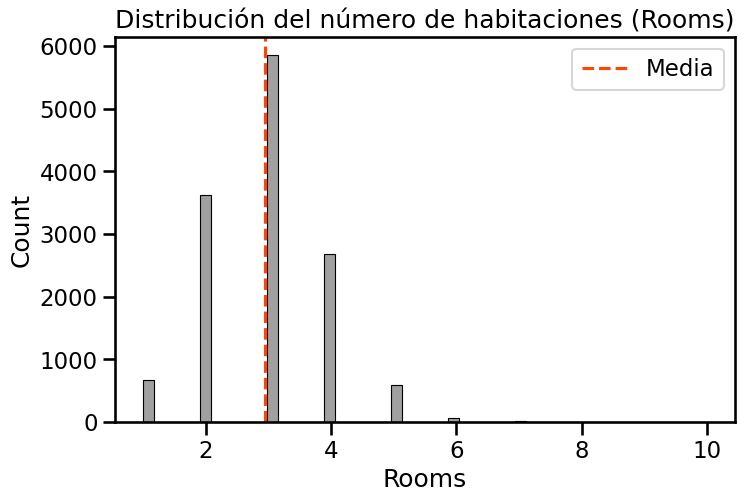

In [380]:
# 2.1.2)

fig, ax = plt.subplots(figsize=(8, 5))

seaborn.histplot(selected_cols_df["Rooms"], bins=50, ax=ax, color='gray')
ax.axvline(selected_cols_df["Rooms"].mean(), color='orangered', linestyle='--', label='Media')
ax.set_title("Distribución del número de habitaciones (Rooms)")
ax.legend()

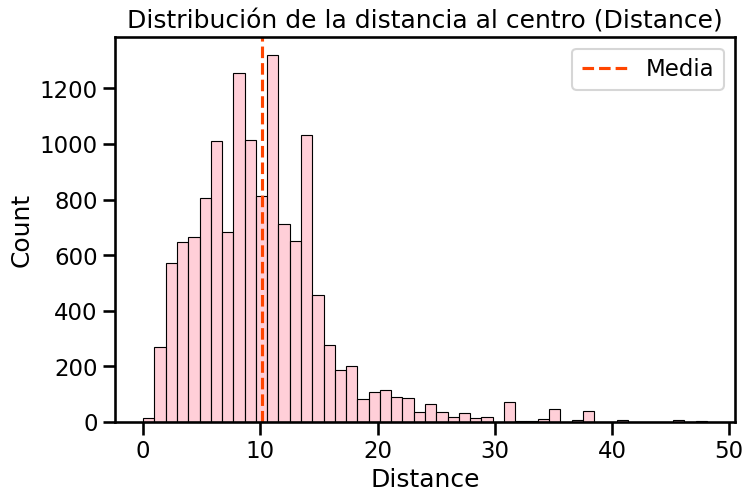

In [381]:
fig, ax = plt.subplots(figsize=(8, 5))

seaborn.histplot(selected_cols_df["Distance"], bins=50, ax=ax, color='pink')
ax.axvline(selected_cols_df["Distance"].mean(), color='orangered', linestyle='--', label='Media')
ax.set_title("Distribución de la distancia al centro (Distance)")
ax.legend()

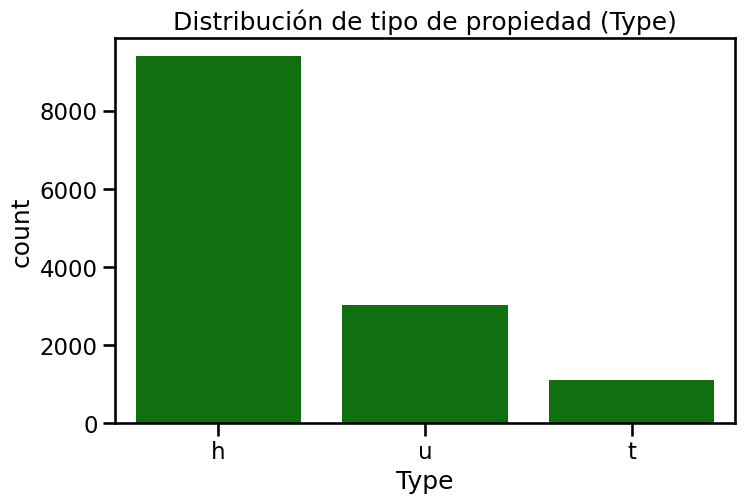

In [382]:
fig, ax = plt.subplots(figsize=(8, 5))

seaborn.countplot(data=selected_cols_df, x="Type", ax=ax, color='green')
ax.set_title("Distribución de tipo de propiedad (Type)")
plt.show()

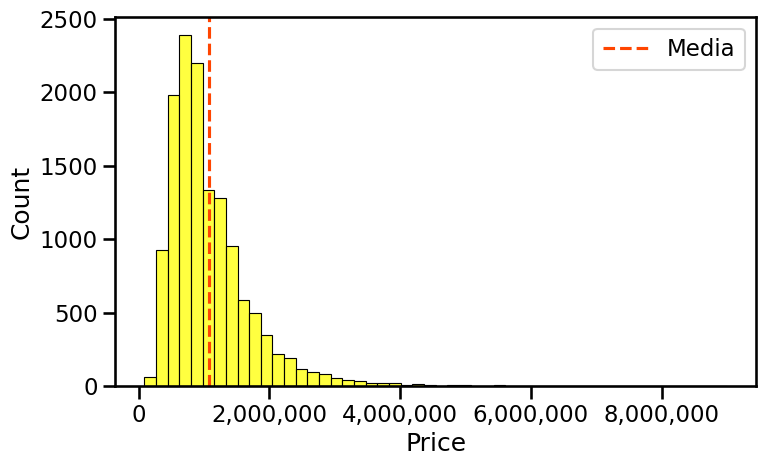

In [383]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(8, 5))

seaborn.histplot(selected_cols_df["Price"], bins=50, ax=ax, color='yellow')
ax.axvline(selected_cols_df["Price"].mean(), color='orangered', linestyle='--', label='Media')
ax.legend()

# Mostrar valores reales en el eje X
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

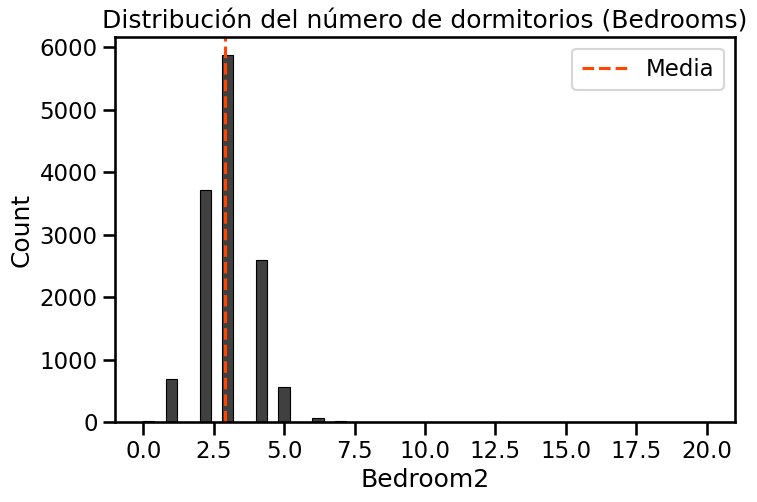

In [384]:
fig, ax = plt.subplots(figsize=(8, 5))

seaborn.histplot(selected_cols_df["Bedroom2"], bins=50, ax=ax, color='black')
ax.axvline(selected_cols_df["Bedroom2"].mean(), color='orangered', linestyle='--', label='Media')
ax.set_title("Distribución del número de dormitorios (Bedrooms)")
ax.legend()

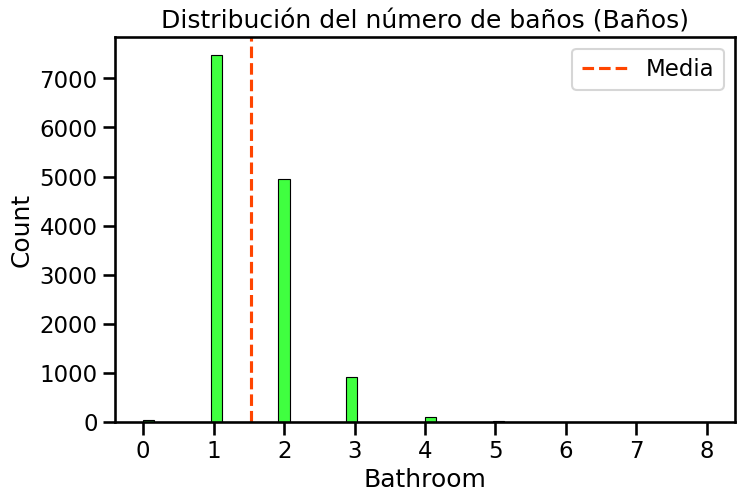

In [385]:
fig, ax = plt.subplots(figsize=(8, 5))

seaborn.histplot(selected_cols_df["Bathroom"], bins=50, ax=ax, color='lime')
ax.axvline(selected_cols_df["Bathroom"].mean(), color='orangered', linestyle='--', label='Media')
ax.set_title("Distribución del número de baños (Baños)")
ax.legend()

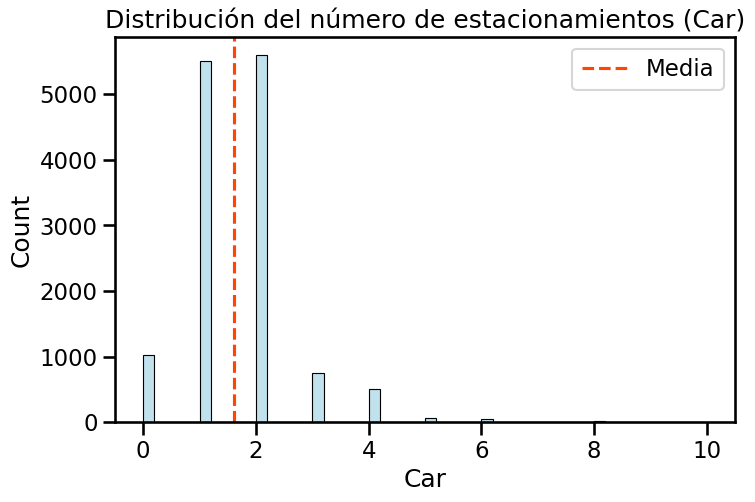

In [386]:
fig, ax = plt.subplots(figsize=(8, 5))

seaborn.histplot(selected_cols_df["Car"], bins=50, ax=ax, color='lightblue')
ax.axvline(selected_cols_df["Car"].mean(), color='orangered', linestyle='--', label='Media')
ax.set_title("Distribución del número de estacionamientos (Car)")
ax.legend()

<ipython-input-387-0c502215bc24>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


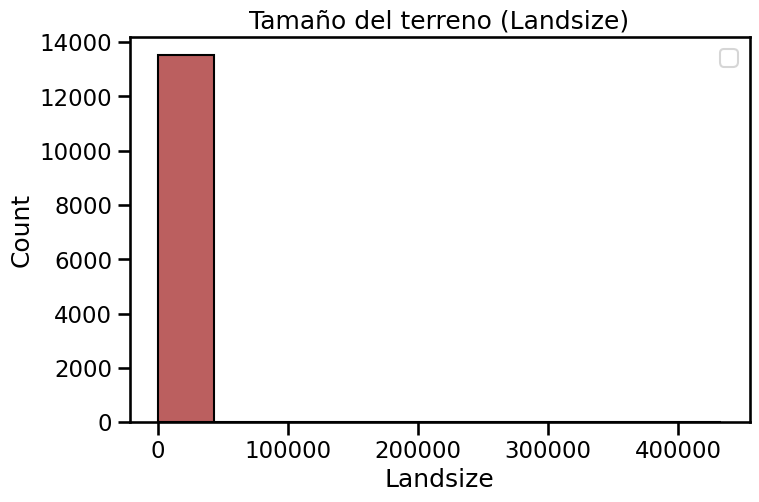

In [387]:
fig, ax = plt.subplots(figsize=(8, 5))

seaborn.histplot(selected_cols_df["Landsize"], bins=10, ax=ax, color='brown')
ax.set_title("Tamaño del terreno (Landsize)")
ax.legend()

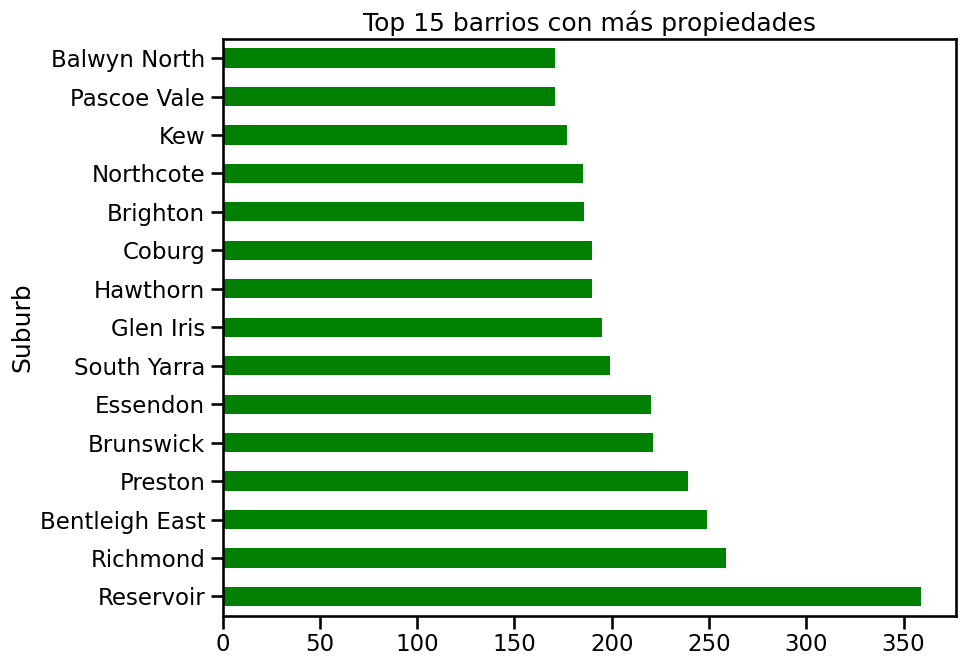

In [388]:
top_suburbs = selected_cols_df['Suburb'].value_counts().nlargest(15)

fig, ax = plt.subplots(figsize=(10, 7))
top_suburbs.plot(kind='barh', color='green', ax=ax)
ax.set_title("Top 15 barrios con más propiedades")
plt.tight_layout()
plt.show()


Rango aceptable para 'Price': [100000, 2345000.0]
Filas antes: 13518, después de eliminar outliers: 12896


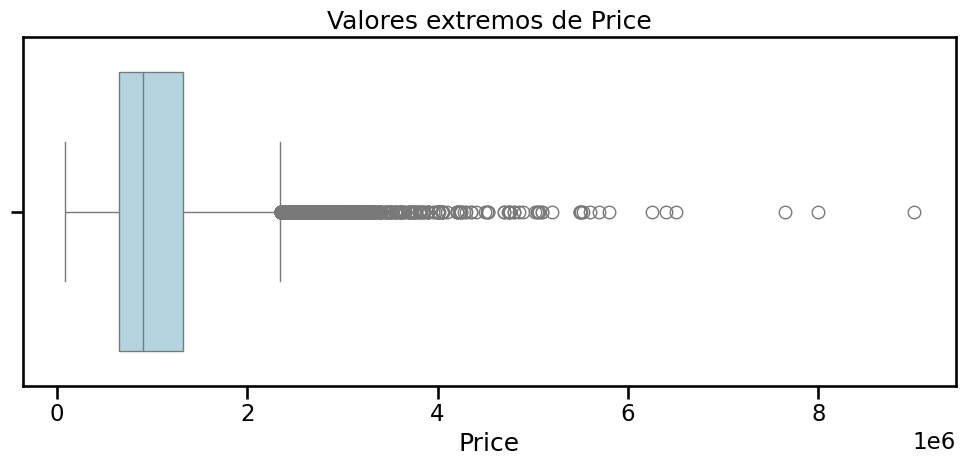

Rango aceptable para 'Distance': [0, 23.2]
Filas antes: 12896, después de eliminar outliers: 12483


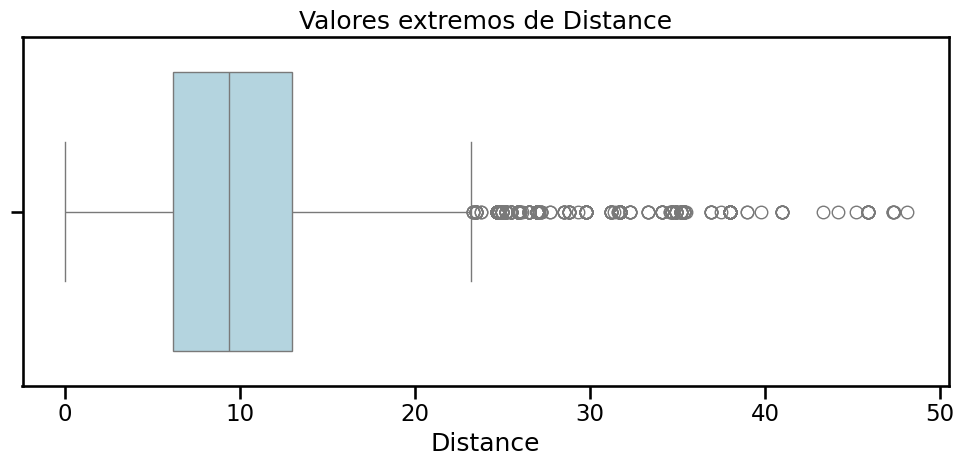

Rango aceptable para 'Bathroom': [0, 3.5]
Filas antes: 12483, después de eliminar outliers: 12430


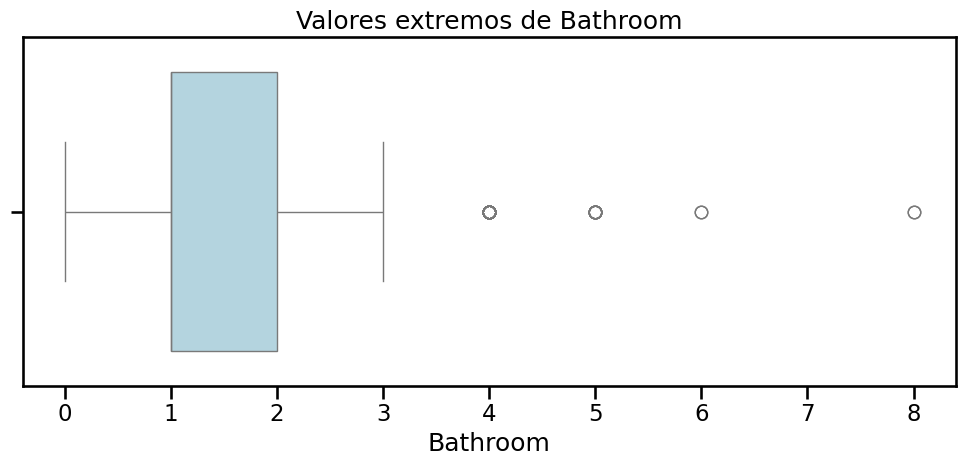

Rango aceptable para 'Bedroom2': [0, 4.5]
Filas antes: 12430, después de eliminar outliers: 12002


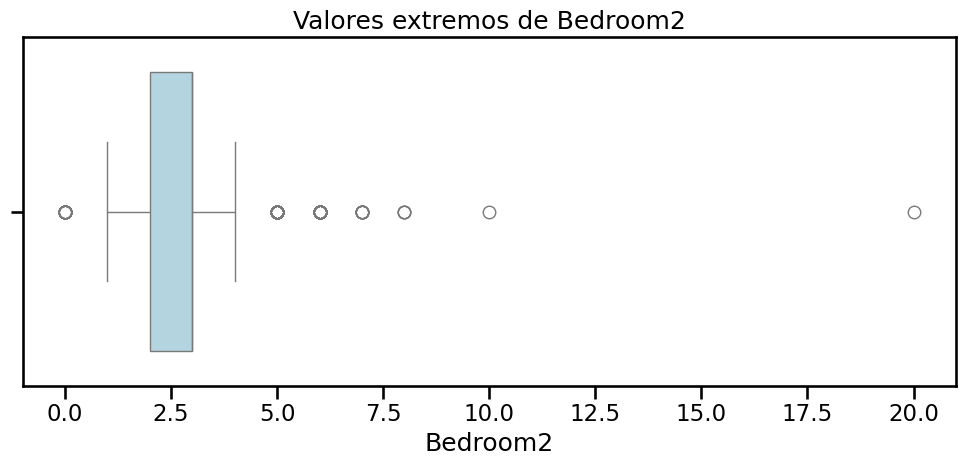

Rango aceptable para 'Car': [0, 3.5]
Filas antes: 12002, después de eliminar outliers: 11547


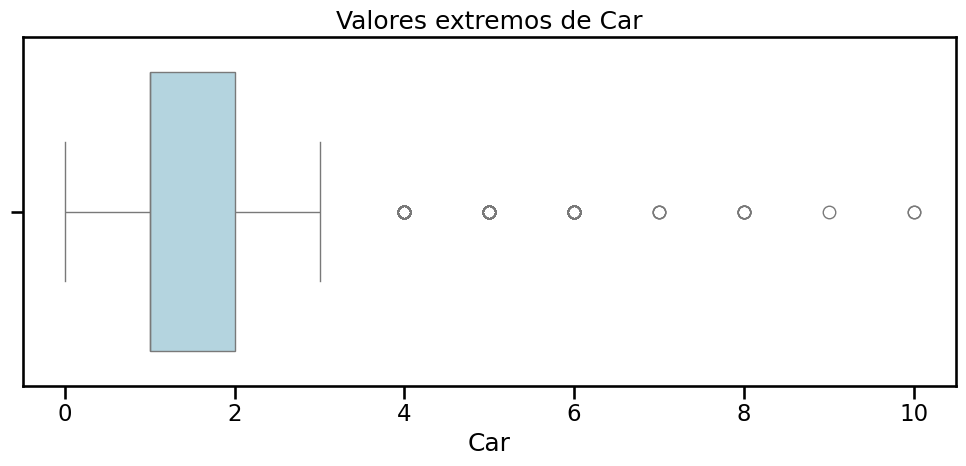

Rango aceptable para 'Rooms': [1, 4.5]
Filas antes: 11547, después de eliminar outliers: 11507


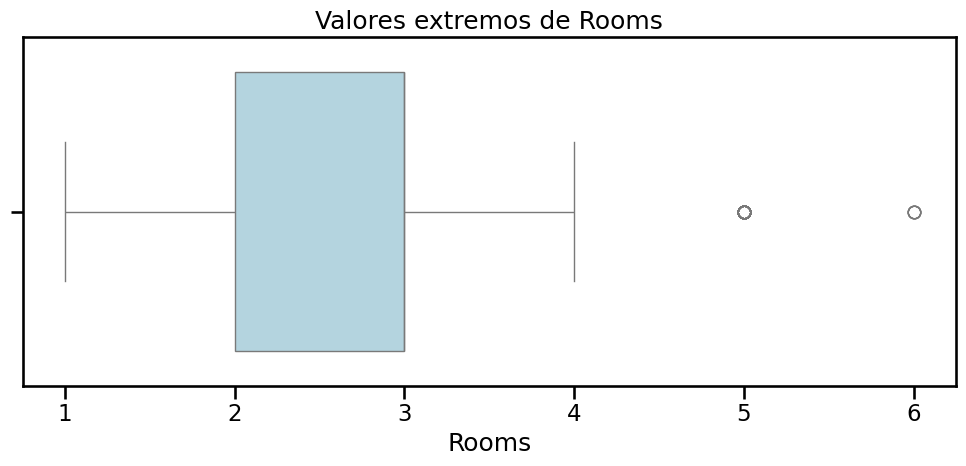

In [389]:
# 2.1.3) & 2.1.4)
# Definimos una función que elimina outliers usando el método de Tukey. La misma muestra un boxplot resaltando los valores extremos.

def remove_outliers_tukey(df, col, custom_lower_bound=None, show_plot=True):

    df[col].describe()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # en algunos casos, el límite inferior puede ser negativo, de ser así fijamos un límite
    if custom_lower_bound is not None:
      lower_bound = custom_lower_bound

    print(f"Rango aceptable para '{col}': [{lower_bound}, {upper_bound}]")

    # Filtrar outliers
    df_filtered = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print(f"Filas antes: {len(df)}, después de eliminar outliers: {len(df_filtered)}")

    if show_plot:
        fig, ax = plt.subplots(figsize=(10, 5))
        seaborn.boxplot(x=df[col], ax=ax, color='lightblue')

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        ax.set_title(f'Valores extremos de {col}')

        stats = df_filtered[col].describe().round(2).to_string()

        plt.tight_layout()
        plt.show()

    return df_filtered

selected_cols_df = remove_outliers_tukey(selected_cols_df, 'Price', 100000)
selected_cols_df = remove_outliers_tukey(selected_cols_df, 'Distance', 0)
selected_cols_df = remove_outliers_tukey(selected_cols_df, 'Bathroom', 0)
selected_cols_df = remove_outliers_tukey(selected_cols_df, 'Bedroom2', 0)
selected_cols_df = remove_outliers_tukey(selected_cols_df, 'Car', 0)
selected_cols_df = remove_outliers_tukey(selected_cols_df, 'Rooms', 1)

# Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

## Ejercicios opcionales:

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)